0.002777777777777778


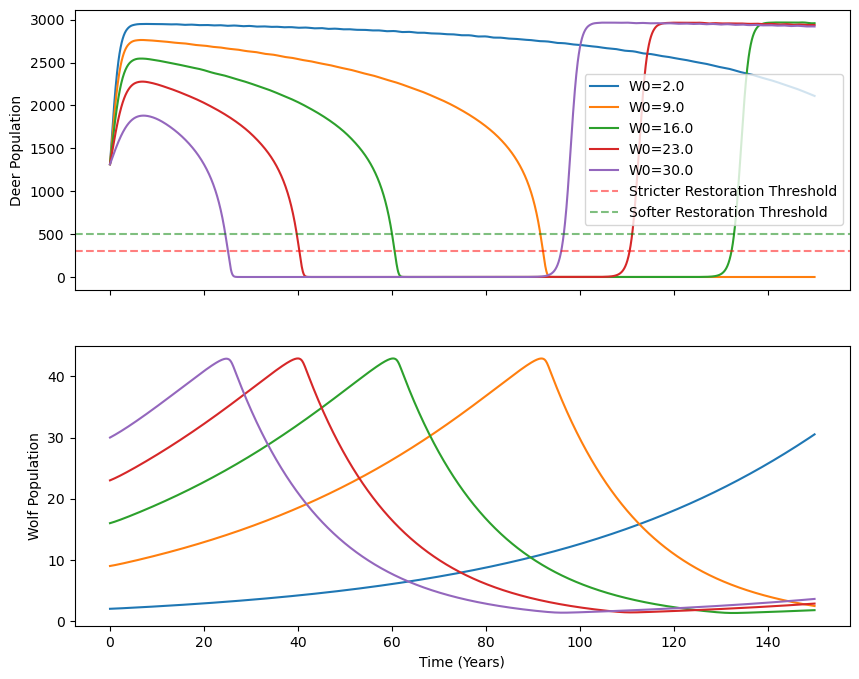

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE system with Holling Type II & Logistic Growth
def wolf_deer_holling(t, y, params):
    D, W = y
    r, e, beta, d, h, K = params
    
    # Holling Type II functional response
    predation = (e * D * W) / (1 + h * e * D)
    
    # Logistic growth for deer + predation
    dDdt = r * D * (1 - D/K) - predation
    
    # Wolf growth based on saturated consumption
    dWdt = beta * predation - d * W
    
    return [dDdt, dWdt]

def simulate_holling(params, D0, W0, t_max=150):
    t_eval = np.linspace(0, t_max, 2000)
    sol = solve_ivp(wolf_deer_holling, [0, t_max], [D0, W0], 
                    args=(params,), t_eval=t_eval, method='RK45')
    return sol.t, sol.y[0], sol.y[1]

# --- Parameters ---
# --- Parameters ---
D_star = 423 #  414
r = 1.138      # deer birth rate - death rate
h = 0.038       # handling time - NOT FULLY ACCURATE
e = -18/(18*h*D_star - D_star) #-18/(18*h*D_star - D_star)  # attack rate - want it to go up to improve dynamics 
d = 0.05       # wolf death rate
beta = (d*(1+h*e*D_star))/(e*D_star)   # conversion efficiency - independent of D_star (as expected) - want it to go up to improve dynamics
print(beta)

K = 27000      # deer carrying capacity
# as D_star goes down, model becomes more sensitive to handling time!

params = (r, e, beta, d, h, K)

# Initial populations
D0 = 11827
W0_values = np.linspace(2, 30, 5) 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for W0 in W0_values:
    t, D, W = simulate_holling(params, D0, W0)
    ax1.plot(t, D, label=f"W0={W0}")
    ax2.plot(t, W, label=f"W0={W0}")

ax1.axhline(300, color='red', linestyle='--', alpha=0.5, label="Stricter Restoration Threshold")
ax1.axhline(500, color='green', linestyle='--', alpha=0.5, label="Softer Restoration Threshold")
ax1.set_ylabel("Deer Population")
ax1.legend()
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("Wolf Population")
plt.show()

In [ ]:
# # --- Parameters --- OLD
# D_star = 414   #
# r = 1.138      # deer birth rate - death rate
# h = 0.03       # handling time 
# e = 0.18/D_star #-18/(18*h*D_star - D_star)  # attack rate - want it to go up to improve dynamics 
# print(e)
# print(18/D_star)
# d = 0.05       # wolf death rate
# beta = (d*(1+h*e*D_star))/(e*D_star)   # conversion efficiency - independent of D_star (as expected) - want it to go up to improve dynamics
# print(beta)
# K = 1700      # deer carrying capacity

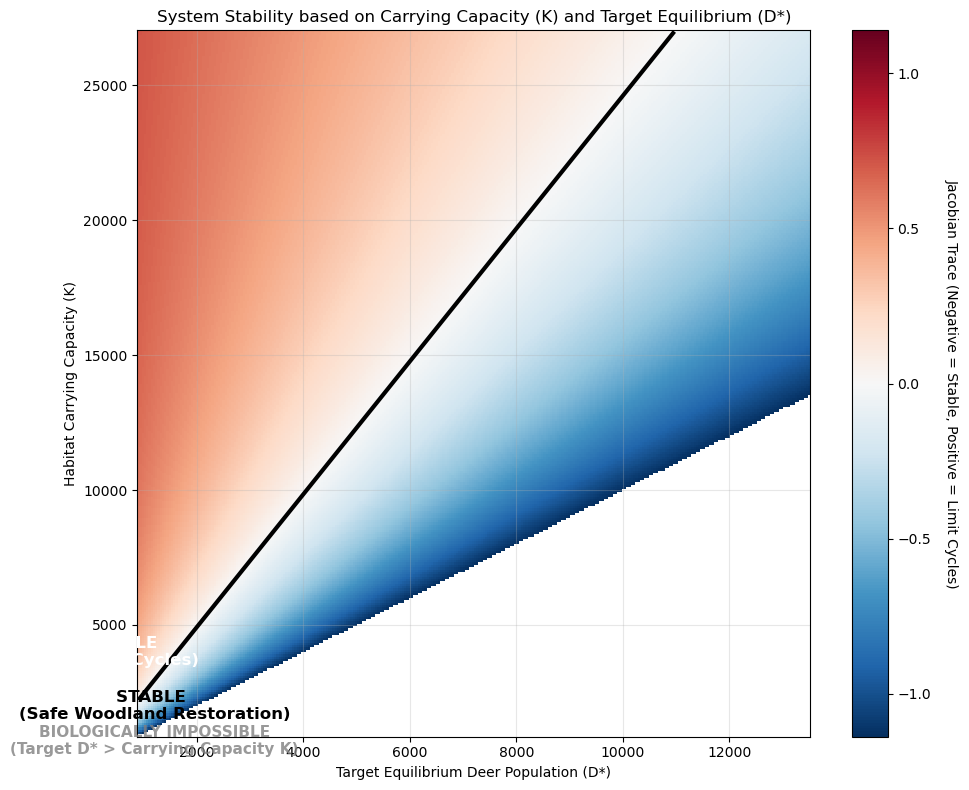

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# --- Fixed Parameters ---
r = 1.138      # deer birth rate - death rate
h = 0.038      # handling time
d = 0.05       # wolf death rate

# --- Parameter Sweep Ranges ---
# Sweeping D_star from 100 to 1500 deer
D_star_vals = np.linspace(100*9, 1500*9, 300)  # 1 until 15 deer per km^2 

# Sweeping Carrying Capacity (K) from 500 to 5000 deer
K_vals = np.linspace(100*9, 3000*9, 300)

# Create a 2D grid for all combinations
D_grid, K_grid = np.meshgrid(D_star_vals, K_vals)

# --- The Math ---
# 1. Calculate 'e' dynamically for the entire grid
e_grid = -18 / (18 * h * D_grid - D_grid)

# 2. Calculate the Trace of the Jacobian for stability
trace_grid = r * (1 - 2 * D_grid / K_grid) - (r * (1 - D_grid / K_grid)) / (1 + h * e_grid * D_grid)

# 3. Mask invalid biological data
# We cannot have a target equilibrium (D*) higher than the environment's carrying capacity (K)
invalid_mask = D_grid >= K_grid
trace_grid = np.ma.masked_where(invalid_mask, trace_grid)

# --- Plotting the Heatmap ---
plt.figure(figsize=(10, 8))

# Plot the stability gradient (Blue = Stable, Red = Unstable)
# We center the colormap at 0 so the visual boundary perfectly matches the math
bound = np.nanmax(np.abs(trace_grid))
heatmap = plt.pcolormesh(D_grid, K_grid, trace_grid, cmap='RdBu_r', vmin=-bound, vmax=bound, shading='auto')

# Draw a thick black line exactly where Trace = 0 (The Bifurcation Boundary)
plt.contour(D_grid, K_grid, trace_grid, levels=[0], colors='black', linewidths=3)

# Formatting
cbar = plt.colorbar(heatmap)
cbar.set_label('Jacobian Trace (Negative = Stable, Positive = Limit Cycles)', rotation=270, labelpad=20)

# Add custom text annotations for the zones
plt.text(1200, 2000, "STABLE \n(Safe Woodland Restoration)", color='black', 
         fontsize=12, fontweight='bold', ha='center', va='center')
plt.text(400, 4000, "UNSTABLE \n(Extinction Cycles)", color='white', 
         fontsize=12, fontweight='bold', ha='center', va='center')
plt.text(1200, 700, "BIOLOGICALLY IMPOSSIBLE\n(Target D* > Carrying Capacity K)", color='gray', 
         fontsize=11, fontweight='bold', ha='center', va='center', alpha=0.8)


plt.title("System Stability based on Carrying Capacity (K) and Target Equilibrium (D*)")
plt.xlabel("Target Equilibrium Deer Population (D*)")
plt.ylabel("Habitat Carrying Capacity (K)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_34712\2623753836.py:37: RuntimeWarning: divide by zero encountered in divide
  e_grid = -18 / (18 * h * D_grid - D_grid)
C:\Users\andre\AppData\Local\Temp\ipykernel_34712\2623753836.py:40: RuntimeWarning: divide by zero encountered in divide
  trace_grid = r * (1 - 2 * D_grid / K_grid) - (r * (1 - D_grid / K_grid)) / (1 + h * e_grid * D_grid)
C:\Users\andre\AppData\Local\Temp\ipykernel_34712\2623753836.py:40: RuntimeWarning: invalid value encountered in divide
  trace_grid = r * (1 - 2 * D_grid / K_grid) - (r * (1 - D_grid / K_grid)) / (1 + h * e_grid * D_grid)
C:\Users\andre\AppData\Local\Temp\ipykernel_34712\2623753836.py:40: RuntimeWarning: invalid value encountered in multiply
  trace_grid = r * (1 - 2 * D_grid / K_grid) - (r * (1 - D_grid / K_grid)) / (1 + h * e_grid * D_grid)
C:\Users\andre\AppData\Local\Temp\ipykernel_34712\2623753836.py:40: RuntimeWarning: invalid value encountered in subtract
  trace_grid = r * (1 - 2 * D_grid / K_gr

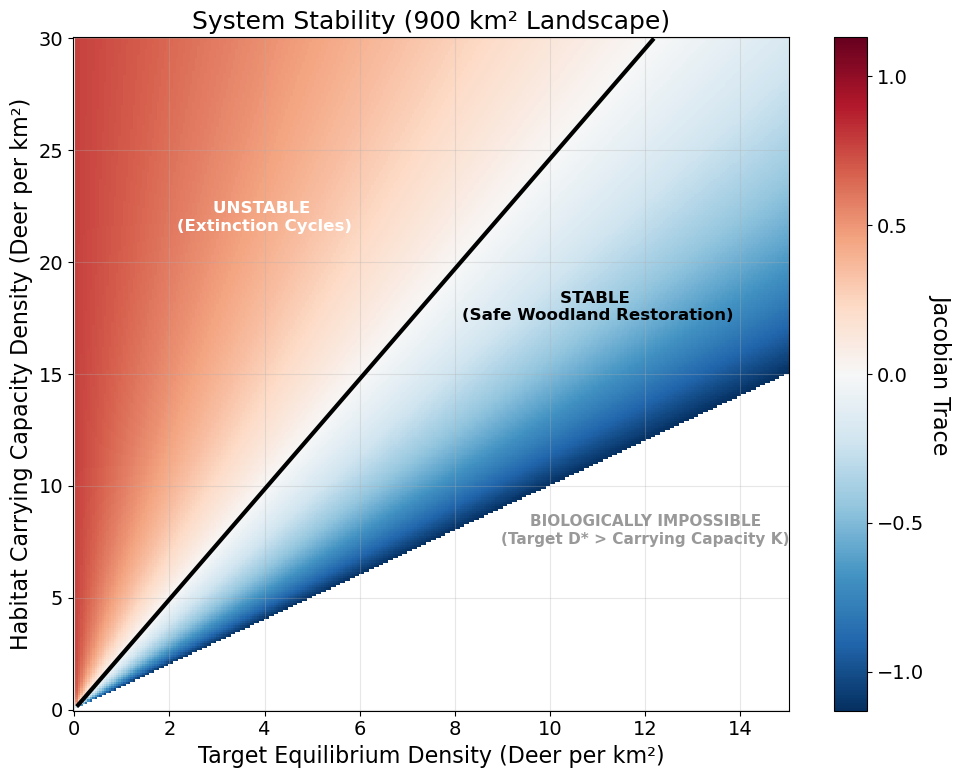

In [112]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,          # Global font size
    'axes.titlesize': 18,     # Title size
    'axes.labelsize': 16,     # X and Y axis label size
    'xtick.labelsize': 14,    # X tick numbers
    'ytick.labelsize': 14,    # Y tick numbers
    'legend.fontsize': 14,    # Legend text size
    'figure.titlesize': 20    # Overall figure title (if used)
})

# ==========================================
# --- SPATIAL SCALING LOGIC ---
# ==========================================
original_area = 100
area_multiplier = 9
new_area = original_area * area_multiplier  # Now evaluating 1800 km^2

# --- Fixed Parameters ---
r = 1.138      # deer birth rate - death rate
h = 0.038      # handling time
d = 0.15       # wolf death rate

# --- Parameter Sweeps (Absolute Numbers) ---
# We scale the original sweeps by 9 so the simulation evaluates the 
# exact same ecological ratios, just in a much larger physical space.
D_star_vals = np.linspace(0 * area_multiplier, 1500 * area_multiplier, 300) 
K_vals = np.linspace(0 * area_multiplier, 3000 * area_multiplier, 300)

# Create 2D grids for absolute populations
D_grid, K_grid = np.meshgrid(D_star_vals, K_vals)

# --- The Math (Must be evaluated using absolute numbers) ---
# Calculate 'e' dynamically based on the absolute grid
e_grid = -18 / (18 * h * D_grid - D_grid)

# Calculate the Trace of the Jacobian for stability
trace_grid = r * (1 - 2 * D_grid / K_grid) - (r * (1 - D_grid / K_grid)) / (1 + h * e_grid * D_grid)

# Mask invalid biological data (Target > Carrying Capacity)
invalid_mask = D_grid >= K_grid
trace_grid = np.ma.masked_where(invalid_mask, trace_grid)

# ==========================================
# --- CONVERT TO DENSITY FOR PLOTTING ---
# ==========================================
# Divide the absolute population grids by the area to get deer/km^2
D_density_grid = D_grid / new_area
K_density_grid = K_grid / new_area

# --- Plotting the Heatmap ---
plt.figure(figsize=(10, 8))

# We use the DENSITY grids for the X and Y axes, but map the calculated Trace to the colors
bound = np.nanmax(np.abs(trace_grid))
heatmap = plt.pcolormesh(D_density_grid, K_density_grid, trace_grid, cmap='RdBu_r', vmin=-bound, vmax=bound, shading='auto')

# Draw the Bifurcation Boundary (Trace = 0)
plt.contour(D_density_grid, K_density_grid, trace_grid, levels=[0], colors='black', linewidths=3)

# Formatting
cbar = plt.colorbar(heatmap)
cbar.set_label('Jacobian Trace', rotation=270, labelpad=20)

# Add custom text annotations using the new DENSITY coordinates
# (e.g., 5 deer/km^2 instead of 1000 deer)
plt.text(11, 18, "STABLE \n(Safe Woodland Restoration)", color='black', 
         fontsize=12, fontweight='bold', ha='center', va='center')

plt.text(4, 22, "UNSTABLE \n(Extinction Cycles)", color='white', 
         fontsize=12, fontweight='bold', ha='center', va='center')

plt.text(12, 8, "BIOLOGICALLY IMPOSSIBLE\n(Target D* > Carrying Capacity K)", color='gray', 
         fontsize=11, fontweight='bold', ha='center', va='center', alpha=0.8)

plt.title(f"System Stability ({new_area} km² Landscape)")
plt.xlabel("Target Equilibrium Density (Deer per km²)")
plt.ylabel("Habitat Carrying Capacity Density (Deer per km²)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

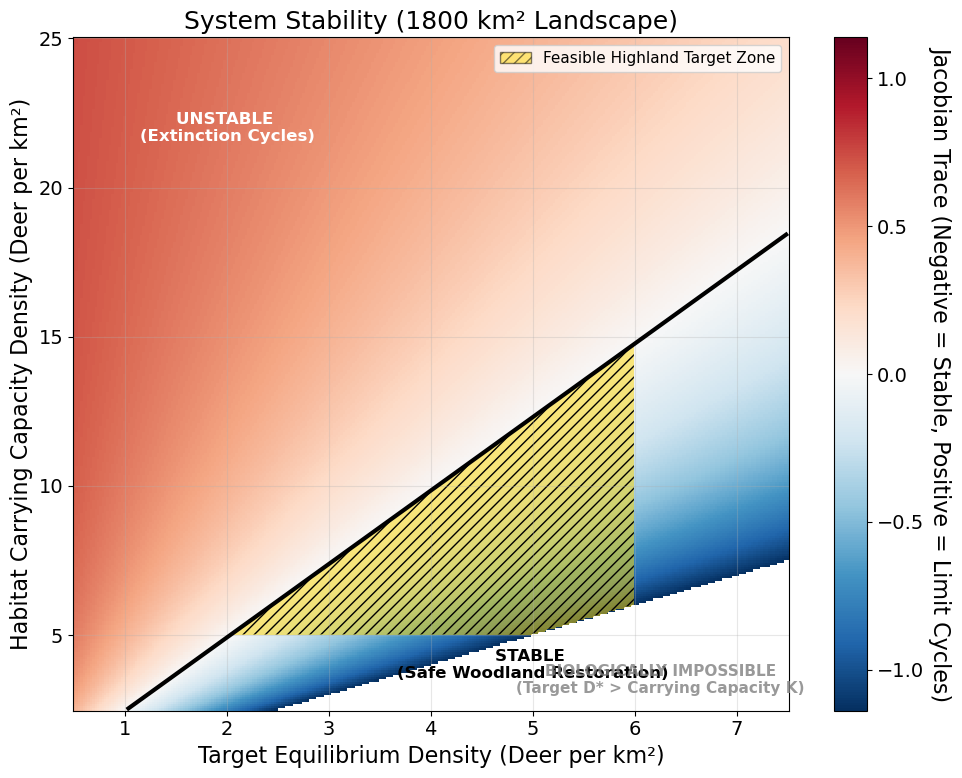

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# --- SPATIAL SCALING LOGIC ---
# ==========================================
original_area = 200
area_multiplier = 9
new_area = original_area * area_multiplier  # 1800 km^2

# --- Fixed Parameters ---
r = 1.138      
h = 0.038      
d = 0.05       

# --- Parameter Sweeps (Absolute Numbers) ---
D_star_vals = np.linspace(100 * area_multiplier, 1500 * area_multiplier, 300) 
K_vals = np.linspace(500 * area_multiplier, 5000 * area_multiplier, 300)

D_grid, K_grid = np.meshgrid(D_star_vals, K_vals)

# --- The Math ---
e_grid = -18 / (18 * h * D_grid - D_grid)
trace_grid = r * (1 - 2 * D_grid / K_grid) - (r * (1 - D_grid / K_grid)) / (1 + h * e_grid * D_grid)

# Mask invalid biological data
invalid_mask = D_grid >= K_grid
trace_grid = np.ma.masked_where(invalid_mask, trace_grid)

# ==========================================
# --- CONVERT TO DENSITY FOR PLOTTING ---
# ==========================================
D_density_grid = D_grid / new_area
K_density_grid = K_grid / new_area

# --- Plotting the Heatmap ---
plt.figure(figsize=(10, 8))

bound = np.nanmax(np.abs(trace_grid))
heatmap = plt.pcolormesh(D_density_grid, K_density_grid, trace_grid, cmap='RdBu_r', vmin=-bound, vmax=bound, shading='auto')

# Draw the Bifurcation Boundary (Trace = 0)
plt.contour(D_density_grid, K_density_grid, trace_grid, levels=[0], colors='black', linewidths=3)

# ==========================================
# --- HIGHLIGHT THE TARGET ZONE ---
# ==========================================
# 1. Define the boolean conditions
in_x_bounds = (D_density_grid >= 2) & (D_density_grid <= 6)
in_y_bounds = (K_density_grid >= 5) & (K_density_grid <= 15)
under_black_line = (trace_grid < 0)  # Trace < 0 is the stable region below the curve

# 2. Combine conditions
target_zone = in_x_bounds & in_y_bounds & under_black_line

# 3. Create a dummy grid to plot the highlight
highlight_grid = np.zeros_like(trace_grid)
highlight_grid[target_zone] = 1

# 4. Plot the hatched overlay (only where highlight_grid == 1)
plt.contourf(D_density_grid, K_density_grid, highlight_grid, levels=[0.5, 1.5], 
             colors=['gold'], alpha=0.5, hatches=['///'])

# 5. Create a custom legend handle for the presentation
highlight_patch = mpatches.Patch(facecolor='gold', alpha=0.5, hatch='///', edgecolor='black', 
                                 label='Feasible Highland Target Zone')
plt.legend(handles=[highlight_patch], loc='upper right', fontsize=11)

# ==========================================
# --- Formatting & Text ---
# ==========================================
cbar = plt.colorbar(heatmap)
cbar.set_label('Jacobian Trace (Negative = Stable, Positive = Limit Cycles)', rotation=270, labelpad=20)

# Text Annotations
plt.text(5, 4, "STABLE \n(Safe Woodland Restoration)", color='black', 
         fontsize=12, fontweight='bold', ha='center', va='center')

plt.text(2, 22, "UNSTABLE \n(Extinction Cycles)", color='white', 
         fontsize=12, fontweight='bold', ha='center', va='center')

plt.text(6.25, 3.5, "BIOLOGICALLY IMPOSSIBLE\n(Target D* > Carrying Capacity K)", color='gray', 
         fontsize=11, fontweight='bold', ha='center', va='center', alpha=0.8)

plt.title(f"System Stability ({new_area} km² Landscape)")
plt.xlabel("Target Equilibrium Density (Deer per km²)")
plt.ylabel("Habitat Carrying Capacity Density (Deer per km²)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()